In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

from scipy.sparse import load_npz

from sklearn.decomposition import (
    NMF,
    TruncatedSVD
)

import matplotlib.pyplot as plt

print("Loading feature matrix...")

X_scaled = load_npz(
    "../features/X_scaled.npz"
)

print("Matrix shape:", X_scaled.shape)

Loading feature matrix...
Matrix shape: (10710, 10200)


In [3]:
feature_names = pd.read_csv(
    "../features/all_feature_names.csv"
)["feature_name"].tolist()

print("Loaded feature names:", len(feature_names))

Loaded feature names: 10200


In [4]:
print("\nRunning reconstruction error analysis...")

k_values = [5, 10, 15, 20, 25, 30]

errors = []

for k in k_values:

    print(f"\nFitting NMF with k={k}")

    model = NMF(
        n_components=k,
        init="nndsvda",
        max_iter=300,
        random_state=42
    )

    model.fit(X_scaled)

    error = model.reconstruction_err_

    errors.append(error)

    print(f"Reconstruction error: {error:.4f}")


Running reconstruction error analysis...

Fitting NMF with k=5
Reconstruction error: 300.1814

Fitting NMF with k=10
Reconstruction error: 296.8596

Fitting NMF with k=15
Reconstruction error: 294.0371

Fitting NMF with k=20
Reconstruction error: 291.5435

Fitting NMF with k=25
Reconstruction error: 289.5462

Fitting NMF with k=30
Reconstruction error: 287.8277


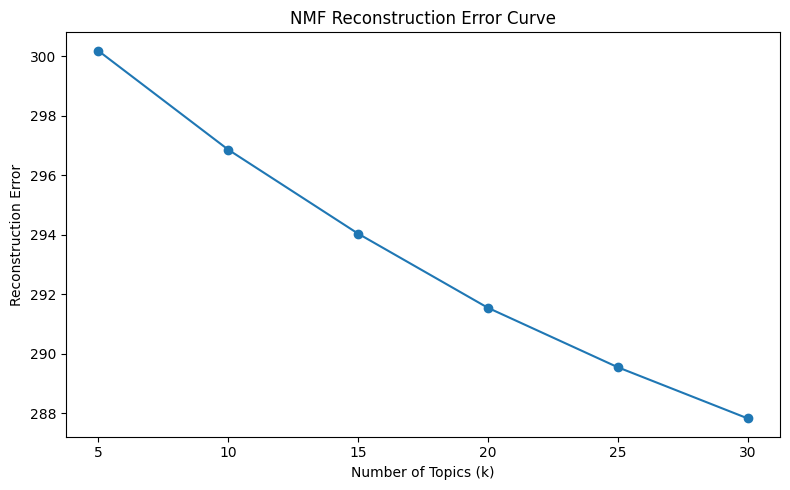

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    errors,
    marker="o"
)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Reconstruction Error")
plt.title("NMF Reconstruction Error Curve")

plt.tight_layout()

plt.savefig(
    "../outputs/nmf_elbow_curve.png",
    dpi=150
)

plt.show()

In [8]:
FINAL_K = 15

print(f"\nUsing FINAL_K = {FINAL_K}")

print("\nFitting final NMF model...")

nmf = NMF(
    n_components=FINAL_K,
    init="nndsvda",
    max_iter=500,
    random_state=42
)

W = nmf.fit_transform(X_scaled)

H = nmf.components_

print("\nNMF complete.")

print("\nW shape:", W.shape)
print("H shape:", H.shape)

print(
    f"\nFinal reconstruction error: "
    f"{nmf.reconstruction_err_:.4f}"
)



Using FINAL_K = 15

Fitting final NMF model...

NMF complete.

W shape: (10710, 15)
H shape: (15, 10200)

Final reconstruction error: 294.0371


In [9]:
np.save(
    "../features/W_nmf.npy",
    W
)

np.save(
    "../features/H_nmf.npy",
    H
)

print("\nSaved W and H matrices.")


Saved W and H matrices.


In [10]:
def print_topic(
    topic_idx,
    top_n=15
):

    top_features = np.argsort(
        H[topic_idx]
    )[::-1][:top_n]

    terms = [
        feature_names[i]
        for i in top_features
    ]

    weights = [
        H[topic_idx][i]
        for i in top_features
    ]

    print("\n" + "=" * 80)

    print(f"TOPIC {topic_idx}")

    print("=" * 80)

    for term, weight in zip(terms, weights):

        print(
            f"{term:<40} "
            f"{weight:.4f}"
        )

print("\n=== TOPIC INTERPRETATION ===")

for i in range(FINAL_K):

    print_topic(i)


=== TOPIC INTERPRETATION ===

TOPIC 0
ICD_3962                                 4.7511
systolic                                 2.0515
dysfunction                              1.8353
ventricular                              1.7782
left ventricular                         1.7195
systolic dysfunction                     1.3534
ventricular systolic                     1.3478
left                                     1.2126
vessel                                   1.1055
ventricular hypertrophy                  0.9219
chest                                    0.7345
regurgitation                            0.6908
chest pain                               0.6842
vessel coronary                          0.6676
hypertrophy                              0.6525

TOPIC 1
abnormalities                            2.1618
airway                                   2.1507
neuromuscular                            2.1374
airway abnormalities                     2.1313
neuromuscular disease                   

In [11]:
dominant_topic = np.argmax(
    W,
    axis=1
)

topic_strength = np.max(
    W,
    axis=1
)

topic_df = pd.DataFrame({
    "dominant_topic": dominant_topic,
    "topic_strength": topic_strength
})

print("\nDominant topic distribution:\n")

print(
    topic_df["dominant_topic"]
    .value_counts()
    .sort_index()
)



Dominant topic distribution:

dominant_topic
0      372
1      183
2     1041
3      124
4      445
5      564
6      445
7     2024
8      423
9     1023
10     824
11     319
12     950
13    1571
14     402
Name: count, dtype: int64


In [12]:
topic_df.to_csv(
    "../features/patient_topics.csv",
    index=False
)

print("\nSaved patient topic assignments.")



Saved patient topic assignments.


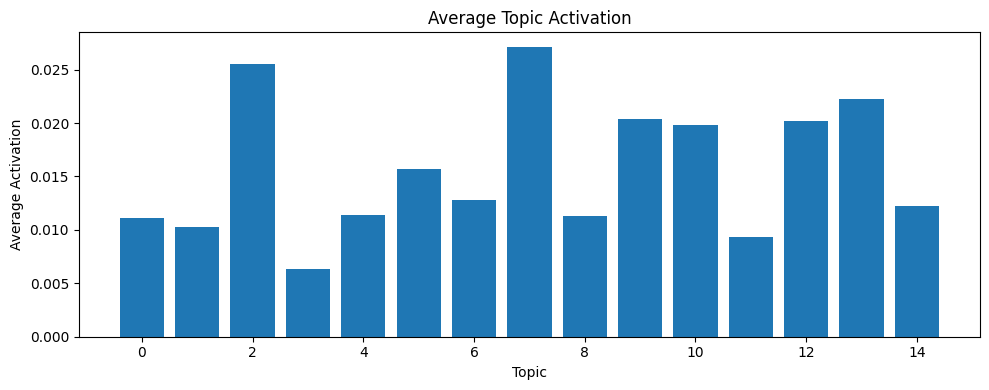

In [14]:
topic_means = W.mean(axis=0)

plt.figure(figsize=(10, 4))

plt.bar(
    range(FINAL_K),
    topic_means
)

plt.xlabel("Topic")
plt.ylabel("Average Activation")
plt.title("Average Topic Activation")

plt.tight_layout()

plt.savefig(
    "../outputs/topic_activation.png",
    dpi=150
)

plt.show()


=== COMPLEXITY SCORE ===

count    10710.000000
mean         1.447152
std          0.944811
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: complexity_score, dtype: float64


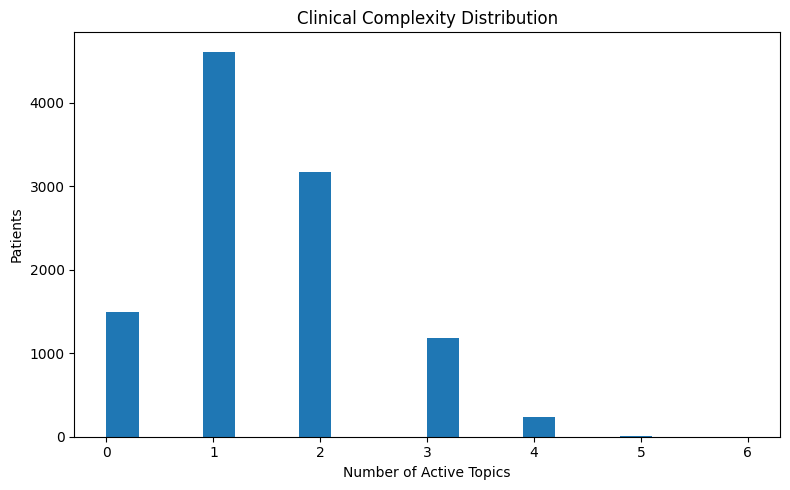

In [15]:
complexity_score = np.sum(
    W > 0.05,
    axis=1
)

complexity_df = pd.DataFrame({
    "complexity_score": complexity_score
})

print("\n=== COMPLEXITY SCORE ===\n")

print(
    complexity_df["complexity_score"]
    .describe()
)

plt.figure(figsize=(8, 5))

plt.hist(
    complexity_score,
    bins=20
)

plt.xlabel("Number of Active Topics")
plt.ylabel("Patients")
plt.title("Clinical Complexity Distribution")

plt.tight_layout()

plt.savefig(
    "../outputs/complexity_distribution.png",
    dpi=150
)

plt.show()

In [16]:
complexity_df.to_csv(
    "../features/complexity_scores.csv",
    index=False
)

print("\nSaved complexity scores.")

print("\nRunning SVD baseline...")

svd = TruncatedSVD(
    n_components=FINAL_K,
    random_state=42
)

W_svd = svd.fit_transform(
    X_scaled
)

print(
    f"\nExplained variance ratio: "
    f"{svd.explained_variance_ratio_.sum():.4f}"
)

np.save(
    "../features/W_svd.npy",
    W_svd
)

print("\nSaved SVD baseline.")


Saved complexity scores.

Running SVD baseline...

Explained variance ratio: 0.0836

Saved SVD baseline.


In [17]:
topic_rows = []

TOP_N_TERMS = 20

for topic_idx in range(FINAL_K):

    top_features = np.argsort(
        H[topic_idx]
    )[::-1][:TOP_N_TERMS]

    for rank, feat_idx in enumerate(top_features):

        topic_rows.append({
            "topic": topic_idx,
            "rank": rank + 1,
            "term": feature_names[feat_idx],
            "weight": H[topic_idx][feat_idx]
        })

topic_terms_df = pd.DataFrame(topic_rows)

topic_terms_df.to_csv(
    "../outputs/topic_terms.csv",
    index=False
)

print("\nSaved topic-term matrix.")


Saved topic-term matrix.


In [18]:
print("\n=== FINAL SUMMARY ===\n")

print("Patients:", W.shape[0])

print("Topics:", W.shape[1])

print("Features:", H.shape[1])

print(
    f"Reconstruction Error: "
    f"{nmf.reconstruction_err_:.4f}"
)

print(
    f"Average Complexity Score: "
    f"{complexity_score.mean():.2f}"
)

print("\nNMF analysis complete.")


=== FINAL SUMMARY ===

Patients: 10710
Topics: 15
Features: 10200
Reconstruction Error: 294.0371
Average Complexity Score: 1.45

NMF analysis complete.
